# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
# sns.set(color_codes=True)

***
## 2. Load data

In [ ]:
df = pd.read_csv('../resources/data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


***
## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [ ]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [ ]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm. 

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging. 

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

In [ ]:
# Add model training in here!
model = RandomForestClassifier(random_state=42) # Add parameters to the model!
model.fit(X=X_train, y=y_train) # Complete this method call!

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

In [ ]:
# Generate predictions here!
y_pred = model.predict(X=X_test)

In [ ]:
# Calculate performance metrics here!
model.score(X_test, y_test)

0.9030668127053669

## Metrics

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

We would like our model to be as precise as possible, thinking that if we can predict what clients will churn, it is possible to offer them better conditions so they decide not to churn.
+ The true positives (TP) for churn=1, will give the clients to contact with a better offer.  
+ The false positives (FP) for churn=1 are clients that may not think to churn, but offering them a better offer is not a bad outcome.  
+ The false negatives (FN) for churn=1 are those clients that will churn and we could not predict, therefore, the company will lose a client.  

The ideal model should have a low number of FN, and additionally low number of FP, so the ratio Recall = (TP /(TP + FN)) should be as close as 1 as we can.



In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3286
           1       0.71      0.05      0.10       366

    accuracy                           0.90      3652
   macro avg       0.81      0.53      0.53      3652
weighted avg       0.89      0.90      0.86      3652



Confusion Matrix

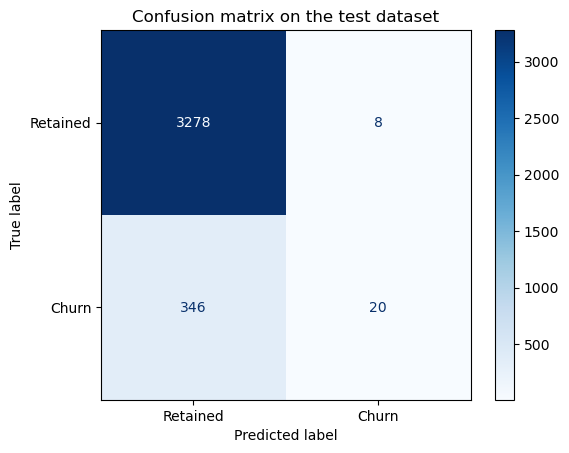

In [ ]:
# confusion_matrix(y_test, y_pred)
class_names=["Retained", "Churn"]

disp = ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=class_names,
        cmap="Blues",
        # normalize="true",
    )
plt.title("Confusion matrix on the test dataset")
plt.show()

On the test dataset, the current model has a good precision and recall for the Retained clients.  
The metrics that matter to us is the **recall** for the **churning clients**, which is not good **(5%)**. There are many clients that churn that are predicted as retained.  

Let's check how are these metrics for the training dataset:

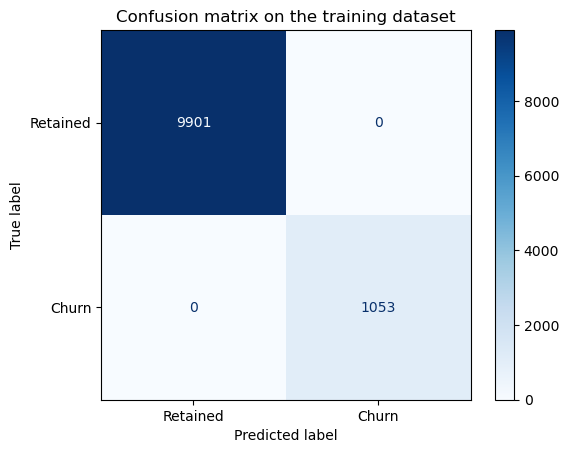

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(
        model,
        X_train,
        y_train,
        display_labels=class_names,
        cmap="Blues",
        # normalize="true",
    )
plt.title("Confusion matrix on the training dataset")
plt.show()

Using the confusion matrix on the training dataset we can see that the model suffers from overfit

# Dealing with overfit

Different parameters that we can modify are:  
+ The number of estimators: "n_estimators"  
+ The maximum depth of the decision trees: "max_depth"  
+ The minimum samples that we allow per split: "min_samples_split"
+ The maximum number of features that can be considered in each node: "max_features"

Another analysis we can perform is the **feature importance** of the dataset, to see what features are used the most to make splits of the dataset.
With this approach we can try to reduce the number of features in our dataset that are not relevant.

We have also observed that the Retained clients are better predicted than those that churn. Let's see the proportion of labels:


In [ ]:
df["churn"].value_counts() / len(df) * 100

churn
0    90.284814
1     9.715186
Name: count, dtype: float64


This problem is known as:  
**"Overfitting caused by class imbalance in a binary classification problem."**

### Testing imbalances in the dataset

Let's try first with the parameter **class_weight** of the Random Forest Classifier: 

In [ ]:
# Baseline model
model_0 = RandomForestClassifier(random_state=42, n_estimators=100) 
model_0.fit(X=X_train, y=y_train)

# New model with class_weight parameter to handle imbalanced data
model_1 = RandomForestClassifier(random_state=42, n_estimators=100, class_weight="balanced") 
model_1.fit(X=X_train, y=y_train)

# New model with class_weight parameter to handle imbalanced data and limit to depth of trees
model_2 = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, class_weight="balanced") 
model_2.fit(X=X_train, y=y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Check recall of the 3 models
recall_0 = metrics.recall_score(y_test, model_0.predict(X=X_test))
recall_1 = metrics.recall_score(y_test, model_1.predict(X=X_test))
recall_2 = metrics.recall_score(y_test, model_2.predict(X=X_test))

print(f"Recall without balancing: {recall_0}")
print(f"Recall with balancing: {recall_1}")
print(f"Recall with balancing and more trees: {recall_2}")
print(classification_report(y_test, model_0.predict(X=X_test)))
print(classification_report(y_test, model_1.predict(X=X_test)))
print(classification_report(y_test, model_2.predict(X=X_test)))


Recall without balancing: 0.0546448087431694
Recall with balancing: 0.0546448087431694
Recall with balancing and more trees: 0.26229508196721313
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3286
           1       0.71      0.05      0.10       366

    accuracy                           0.90      3652
   macro avg       0.81      0.53      0.53      3652
weighted avg       0.89      0.90      0.86      3652

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3286
           1       0.83      0.05      0.10       366

    accuracy                           0.90      3652
   macro avg       0.87      0.53      0.53      3652
weighted avg       0.90      0.90      0.86      3652

              precision    recall  f1-score   support

           0       0.92      0.89      0.90      3286
           1       0.21      0.26      0.24       366

    accuracy                         

Let's check the depth of the trees of the baseline model:

In [ ]:
# Get the depth of each tree
tree_depths = [estimator.tree_.max_depth for estimator in model_0.estimators_]

print("Average tree depth:", sum(tree_depths)/len(tree_depths))
print("Max tree depth:", max(tree_depths))
print("Min tree depth:", min(tree_depths))

Average tree depth: 32.49
Max tree depth: 43
Min tree depth: 25


We can see at least two effects in the recall for class 1:  
1. The baseline Random Forest allows the trees to grow too much, overfitting the training dataset.  
2. The **class_weight** parameter of the Random Forest does not have any influence in the results as long as we don't solve the overfitting due to the max depth of the decision trees.  
3. Once we limit the depth of the decision trees in our random forest, the **class_weight** improves the recall from a **5%** to a **26%**

### Trees max depth

In [ ]:
def rf_train_and_metric(X_train, y_train, X_test, y_test, ax=None, **kwargs):
    model = RandomForestClassifier(
        **kwargs 
        ) 

    model.fit(X=X_train, y=y_train) # Complete this method call!

    class_names=["Retained", "Churn"]

    disp = ConfusionMatrixDisplay.from_estimator(
            model,
            X_test,
            y_test,
            display_labels=class_names,
            cmap="Blues",
            # normalize="true",
            ax=ax if ax is not None else None
        )
    # plt.title("Confusion matrix on the test dataset")
    # plt.show()

Testing max_depth=20
Testing max_depth=15
Testing max_depth=10
Testing max_depth=5


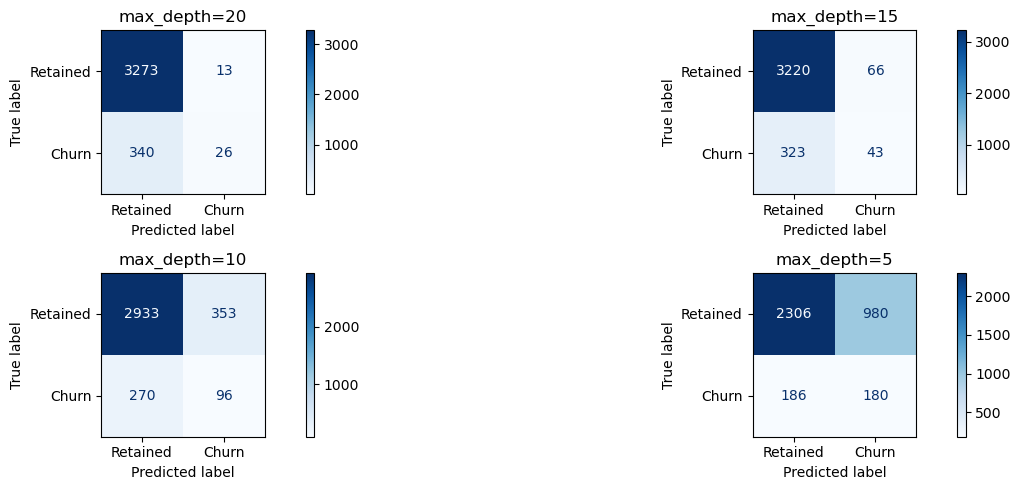

In [ ]:
params = dict(
    random_state=42,
    n_estimators=100,
    class_weight='balanced',
)


fig, axs = plt.subplots(2, 2, figsize=(15, 5))

for i, depth in enumerate([20, 15, 10, 5]):
    ax = axs.flatten()[i]
    ax.set_title(f"max_depth={depth}")

    params['max_depth'] = depth
    print(f"Testing max_depth={depth}")
    rf_train_and_metric(X_train, y_train, X_test, y_test, ax, **params)

plt.tight_layout()
plt.show()

### Number of trees

Let's see if we can improve by selecting a bigger Random Forest

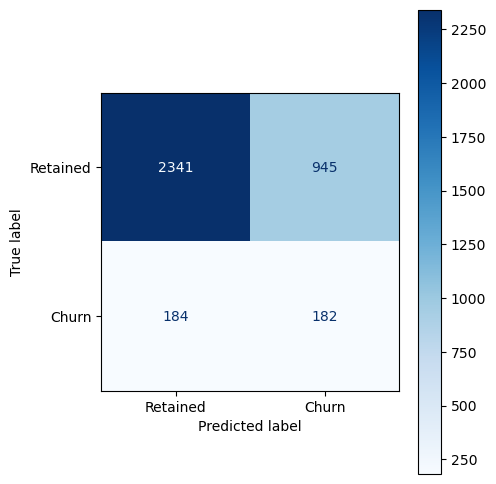

In [ ]:
params = dict(
    random_state=42,
    n_estimators=1000,
    class_weight='balanced',
    max_depth=5
)

fig,ax = plt.subplots(1, 1, figsize=(5, 5))
rf_train_and_metric(X_train, y_train, X_test, y_test, ax, **params)
plt.tight_layout()
plt.show()

Increasing the number of decision trees did not affect the results after adjusting the max depth of the decision trees in the forest.

### Minimum samples in a split

Testing min_samples_split=200
Testing min_samples_split=100
Testing min_samples_split=10
Testing min_samples_split=5


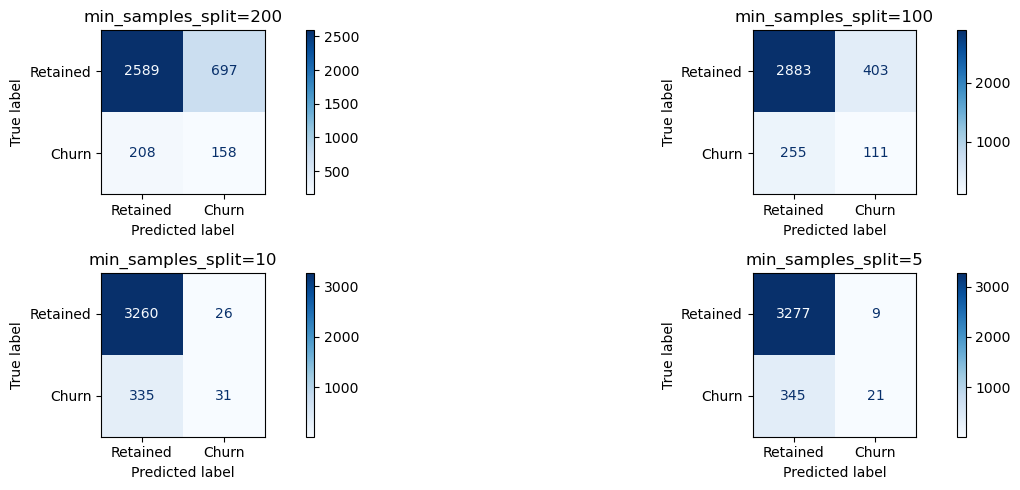

In [ ]:
params = dict(
    random_state=42,
    n_estimators=100,
    class_weight='balanced',
    # max_depth=5
)

fig, axs = plt.subplots(2, 2, figsize=(15, 5))

for i, min_samples_split in enumerate([200, 100, 10, 5]):
    ax = axs.flatten()[i]
    ax.set_title(f"min_samples_split={min_samples_split}")

    params['min_samples_split'] = min_samples_split
    print(f"Testing min_samples_split={min_samples_split}")
    rf_train_and_metric(X_train, y_train, X_test, y_test, ax, **params)

plt.tight_layout()
plt.show()

There are better results by setting the max depth of the trees

### Min samples leaf

Testing min_samples_leaf=200
Testing min_samples_leaf=100
Testing min_samples_leaf=10
Testing min_samples_leaf=5


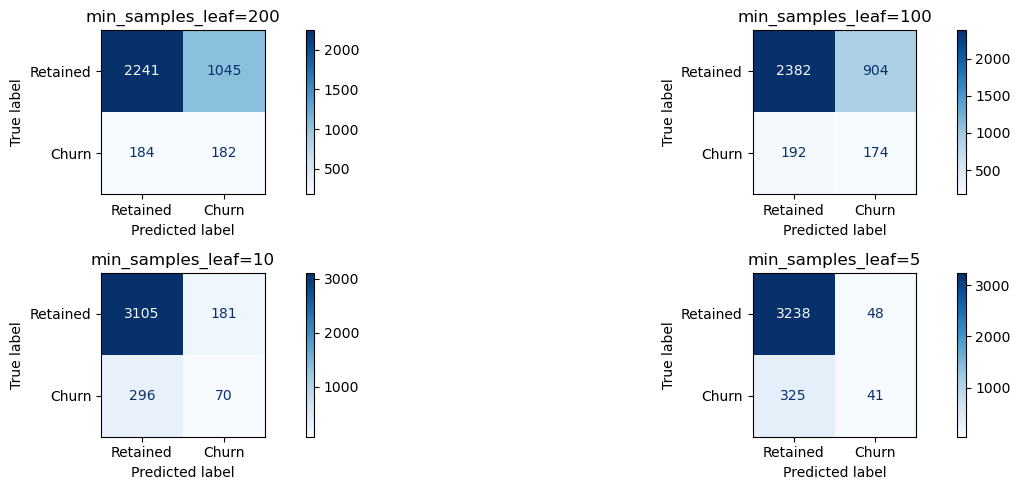

In [ ]:
params = dict(
    random_state=42,
    n_estimators=100,
    class_weight='balanced',
    # max_depth=5
)

fig, axs = plt.subplots(2, 2, figsize=(15, 5))

for i, min_samples_leaf in enumerate([200, 100, 10, 5]):
    ax = axs.flatten()[i]
    ax.set_title(f"min_samples_leaf={min_samples_leaf}")

    params['min_samples_leaf'] = min_samples_leaf
    print(f"Testing min_samples_leaf={min_samples_leaf}")
    rf_train_and_metric(X_train, y_train, X_test, y_test, ax, **params)

plt.tight_layout()
plt.show()


Still the best parameter is to set the maximum depth of the trees.

### Max features

Testing max_features=sqrt
Testing max_features=log2
Testing max_features=10
Testing max_features=2


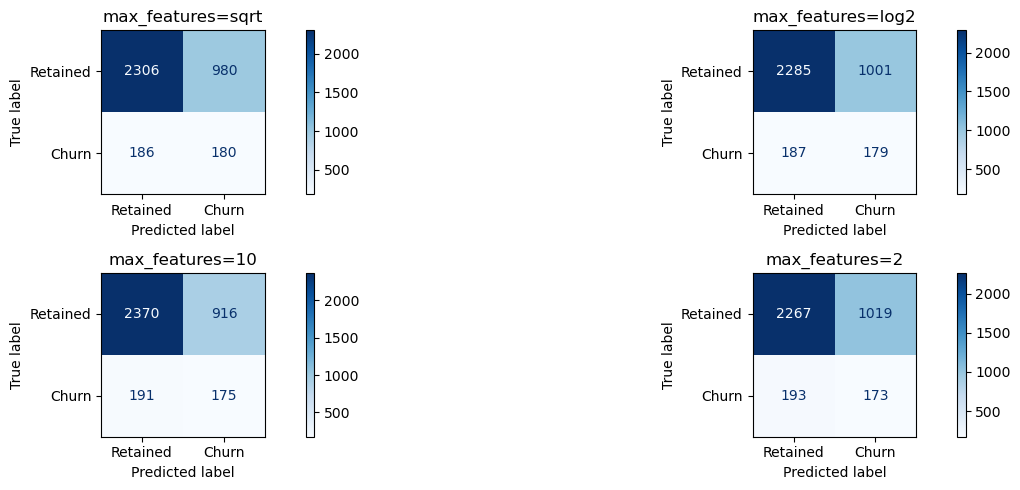

In [ ]:
params = dict(
    random_state=42,
    n_estimators=100,
    class_weight='balanced',
    max_depth=5
)

fig, axs = plt.subplots(2, 2, figsize=(15, 5))

for i, max_features in enumerate(['sqrt', 'log2', 10, 2]):
    ax = axs.flatten()[i]
    ax.set_title(f"max_features={max_features}")

    params['max_features'] = max_features
    print(f"Testing max_features={max_features}")
    rf_train_and_metric(X_train, y_train, X_test, y_test, ax, **params)

plt.tight_layout()
plt.show()

It does not alter significantly the results.

# Remove fields

It seems that removing fields does not improve the predictions for the churning clients

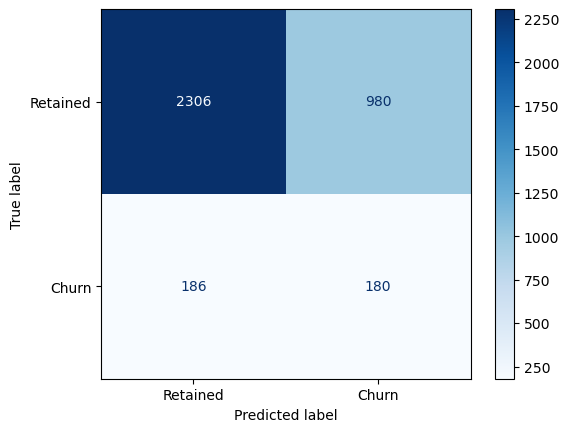

In [ ]:
params = dict(
    random_state=42,
    n_estimators=100,
    class_weight='balanced',
    max_depth=5
)

model_b = RandomForestClassifier(**params) 

model_b.fit(X=X_train, y=y_train) # Complete this method call!
disp = ConfusionMatrixDisplay.from_estimator(
        model_b,
        X_test,
        y_test,
        display_labels=class_names,
        cmap="Blues",
        # normalize="true",
    )

In [ ]:
imp_df = pd.DataFrame({
    "Varname": X_train.columns,
    "Imp": model_b.feature_importances_
})

imp_df.sort_values(by="Imp", ascending=False)


,Varname,Imp
11,margin_gross_pow_ele,0.102918
12,margin_net_pow_ele,0.100517
49,months_activ,0.065321
60,origin_up_lxidpiddsbxsbosboudacockeimpuepw,0.052714
0,cons_12m,0.050827
...,...,...
33,var_6m_price_mid_peak,0.001791
57,channel_usilxuppasemubllopkaafesmlibmsdf,0.001620
30,var_6m_price_mid_peak_fix,0.001446
4,forecast_discount_energy,0.001276


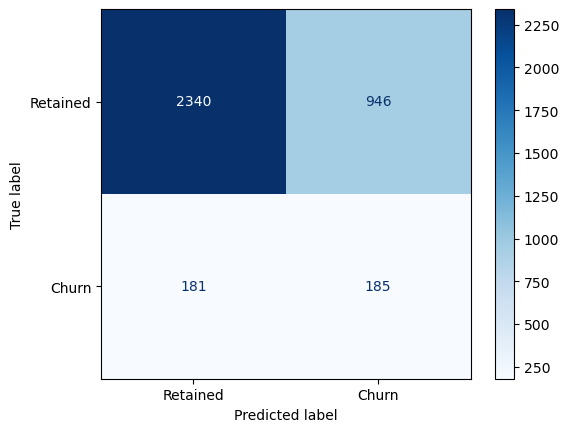

,Varname,Imp
0,margin_gross_pow_ele,0.148411
1,margin_net_pow_ele,0.128503
2,months_activ,0.061668
3,origin_up_lxidpiddsbxsbosboudacockeimpuepw,0.058457
4,cons_12m,0.054984
5,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,0.046476
6,forecast_meter_rent_12m,0.030946
7,months_modif_prod,0.030923
8,tenure,0.046165
9,cons_last_month,0.038057


In [ ]:
perc_feat = 0.5
imp_df.sort_values(by="Imp", ascending=False, inplace=True)

# Number of features to keep in dataset
n_features = int(perc_feat*len(imp_df))
best_features = imp_df[:n_features]["Varname"]

Xf_train = X_train[best_features]
Xf_test = X_test[best_features]

params = dict(
    random_state=42,
    n_estimators=100,
    class_weight='balanced',
    max_depth=5
)

# Refit with less features
model_b.fit(X=Xf_train, y=y_train) # Complete this method call!

disp = ConfusionMatrixDisplay.from_estimator(
        model_b,
        Xf_test,
        y_test,
        display_labels=class_names,
        cmap="Blues",
        # normalize="true",
    )
plt.show()

impf_df = pd.DataFrame({
    "Varname": Xf_train.columns,
    "Imp": model_b.feature_importances_
})
impf_df

In [ ]:
imp_df[:10]

,Varname,Imp
11,margin_gross_pow_ele,0.102918
12,margin_net_pow_ele,0.100517
49,months_activ,0.065321
60,origin_up_lxidpiddsbxsbosboudacockeimpuepw,0.052714
0,cons_12m,0.050827
58,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,0.046333
5,forecast_meter_rent_12m,0.035954
51,months_modif_prod,0.033384
48,tenure,0.033266
2,cons_last_month,0.033152


# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score


Check max depth of the trees in the default Random Forest

In [ ]:
# Get the depth of each tree
tree_depths = [estimator.tree_.max_depth for estimator in model.estimators_]

print("Average tree depth:", sum(tree_depths)/len(tree_depths))
print("Max tree depth:", max(tree_depths))
print("Min tree depth:", min(tree_depths))

Average tree depth: 32.49
Max tree depth: 43
Min tree depth: 25


Let's define the score that we are looking to optimize in our grid search

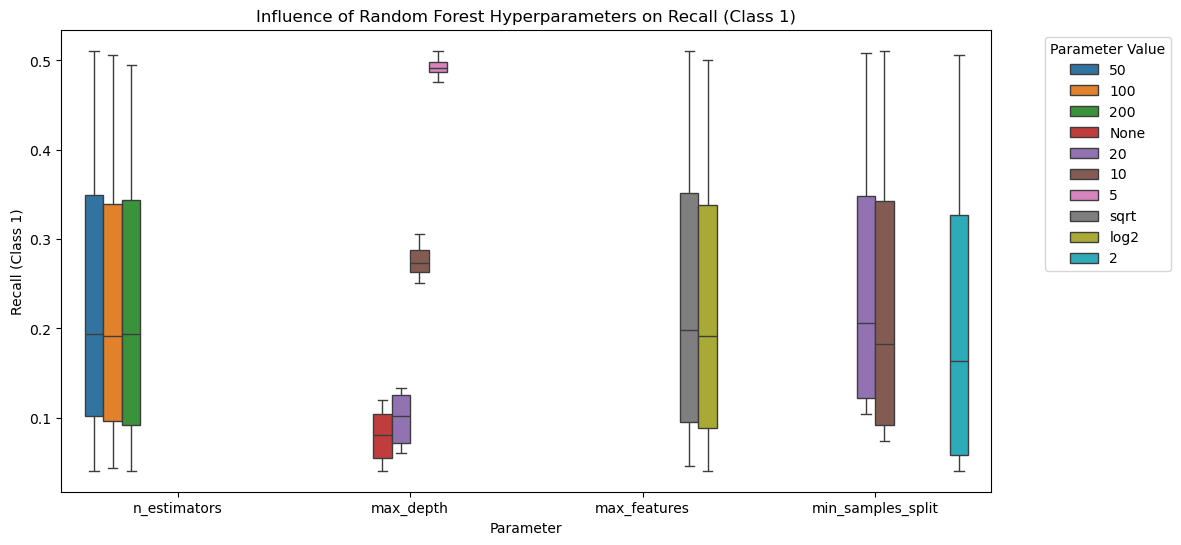

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score
from itertools import product

# Define hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 20, 10, 5],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 10, 20],
}

results = []

# Train models with all combinations
for n, d, f, m in product(param_grid["n_estimators"],
                          param_grid["max_depth"],
                          param_grid["max_features"],
                          param_grid["min_samples_split"]):
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=d,
        max_features=f,
        min_samples_split=m,
        random_state=42,
        class_weight='balanced',
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    recall = recall_score(y_test, y_pred, pos_label=1)
    results.append({
        "n_estimators": n,
        "max_depth": "None" if d is None else d,
        "max_features": f,
        "min_samples_split": m,
        "recall_class1": recall
    })

df_results = pd.DataFrame(results)

# Melt dataframe for easier plotting
df_melted = df_results.melt(
    id_vars="recall_class1",
    value_vars=["n_estimators", "max_depth", "max_features", "min_samples_split"],
    var_name="Parameter",
    value_name="Value"
)

# Plot influence of all parameters
plt.figure(figsize=(12, 6))
sns.boxplot(x="Parameter", y="recall_class1", hue="Value", data=df_melted)
plt.title("Influence of Random Forest Hyperparameters on Recall (Class 1)")
plt.ylabel("Recall (Class 1)")
plt.legend(title="Parameter Value", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

params = {
    'max_depth': [20, 10, 5],
    'min_samples_leaf': [1, 2, 5, 10],
    'n_estimators': [100, 500]
}

# recall_for_one=recall_score(y_test, y_pred, pos_label=1)
recall_for_one = make_scorer(recall_score, pos_label=1)

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 5,
                           n_jobs=-1, verbose=1, 
                           scoring=recall_for_one)


In [ ]:

%%time
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


CPU times: user 2.96 s, sys: 518 ms, total: 3.48 s
Wall time: 1min 47s


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [20, 10, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 500]}"
,scoring,"make_scorer(r..., pos_label=1)"
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [ ]:
grid_search.best_score_

np.float64(0.5318573685398329)

In [ ]:
rf_best = grid_search.best_estimator_
rf_best

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


              precision    recall  f1-score   support

           0       0.93      0.70      0.80      3286
           1       0.16      0.50      0.24       366

    accuracy                           0.68      3652
   macro avg       0.54      0.60      0.52      3652
weighted avg       0.85      0.68      0.74      3652



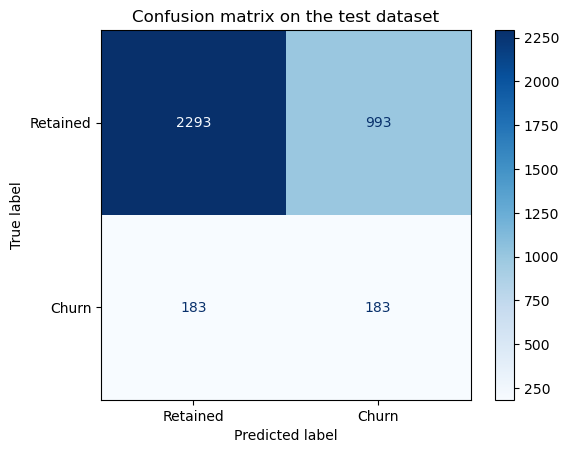

In [ ]:
y_pred = rf_best.predict(X=X_test)
print(classification_report(y_true=y_test, y_pred=y_pred))


class_names=["Retained", "Churn"]
disp = ConfusionMatrixDisplay.from_estimator(
        rf_best,
        X_test,
        y_test,
        display_labels=class_names,
        cmap="Blues",
        # normalize="true",
    )
plt.title("Confusion matrix on the test dataset")
plt.show()

In [ ]:
print("Report with train dataset")
yt_pred = rf_best.predict(X=X_train)
print(classification_report(y_true=y_train, y_pred=yt_pred))

print("Report with test dataset")
y_pred = rf_best.predict(X=X_test)
print(classification_report(y_true=y_test, y_pred=y_pred))

Report with train dataset
              precision    recall  f1-score   support

           0       0.95      0.71      0.81      9901
           1       0.19      0.65      0.30      1053

    accuracy                           0.70     10954
   macro avg       0.57      0.68      0.55     10954
weighted avg       0.88      0.70      0.76     10954

Report with test dataset
              precision    recall  f1-score   support

           0       0.93      0.70      0.80      3286
           1       0.16      0.50      0.24       366

    accuracy                           0.68      3652
   macro avg       0.54      0.60      0.52      3652
weighted avg       0.85      0.68      0.74      3652



# Plot Tree

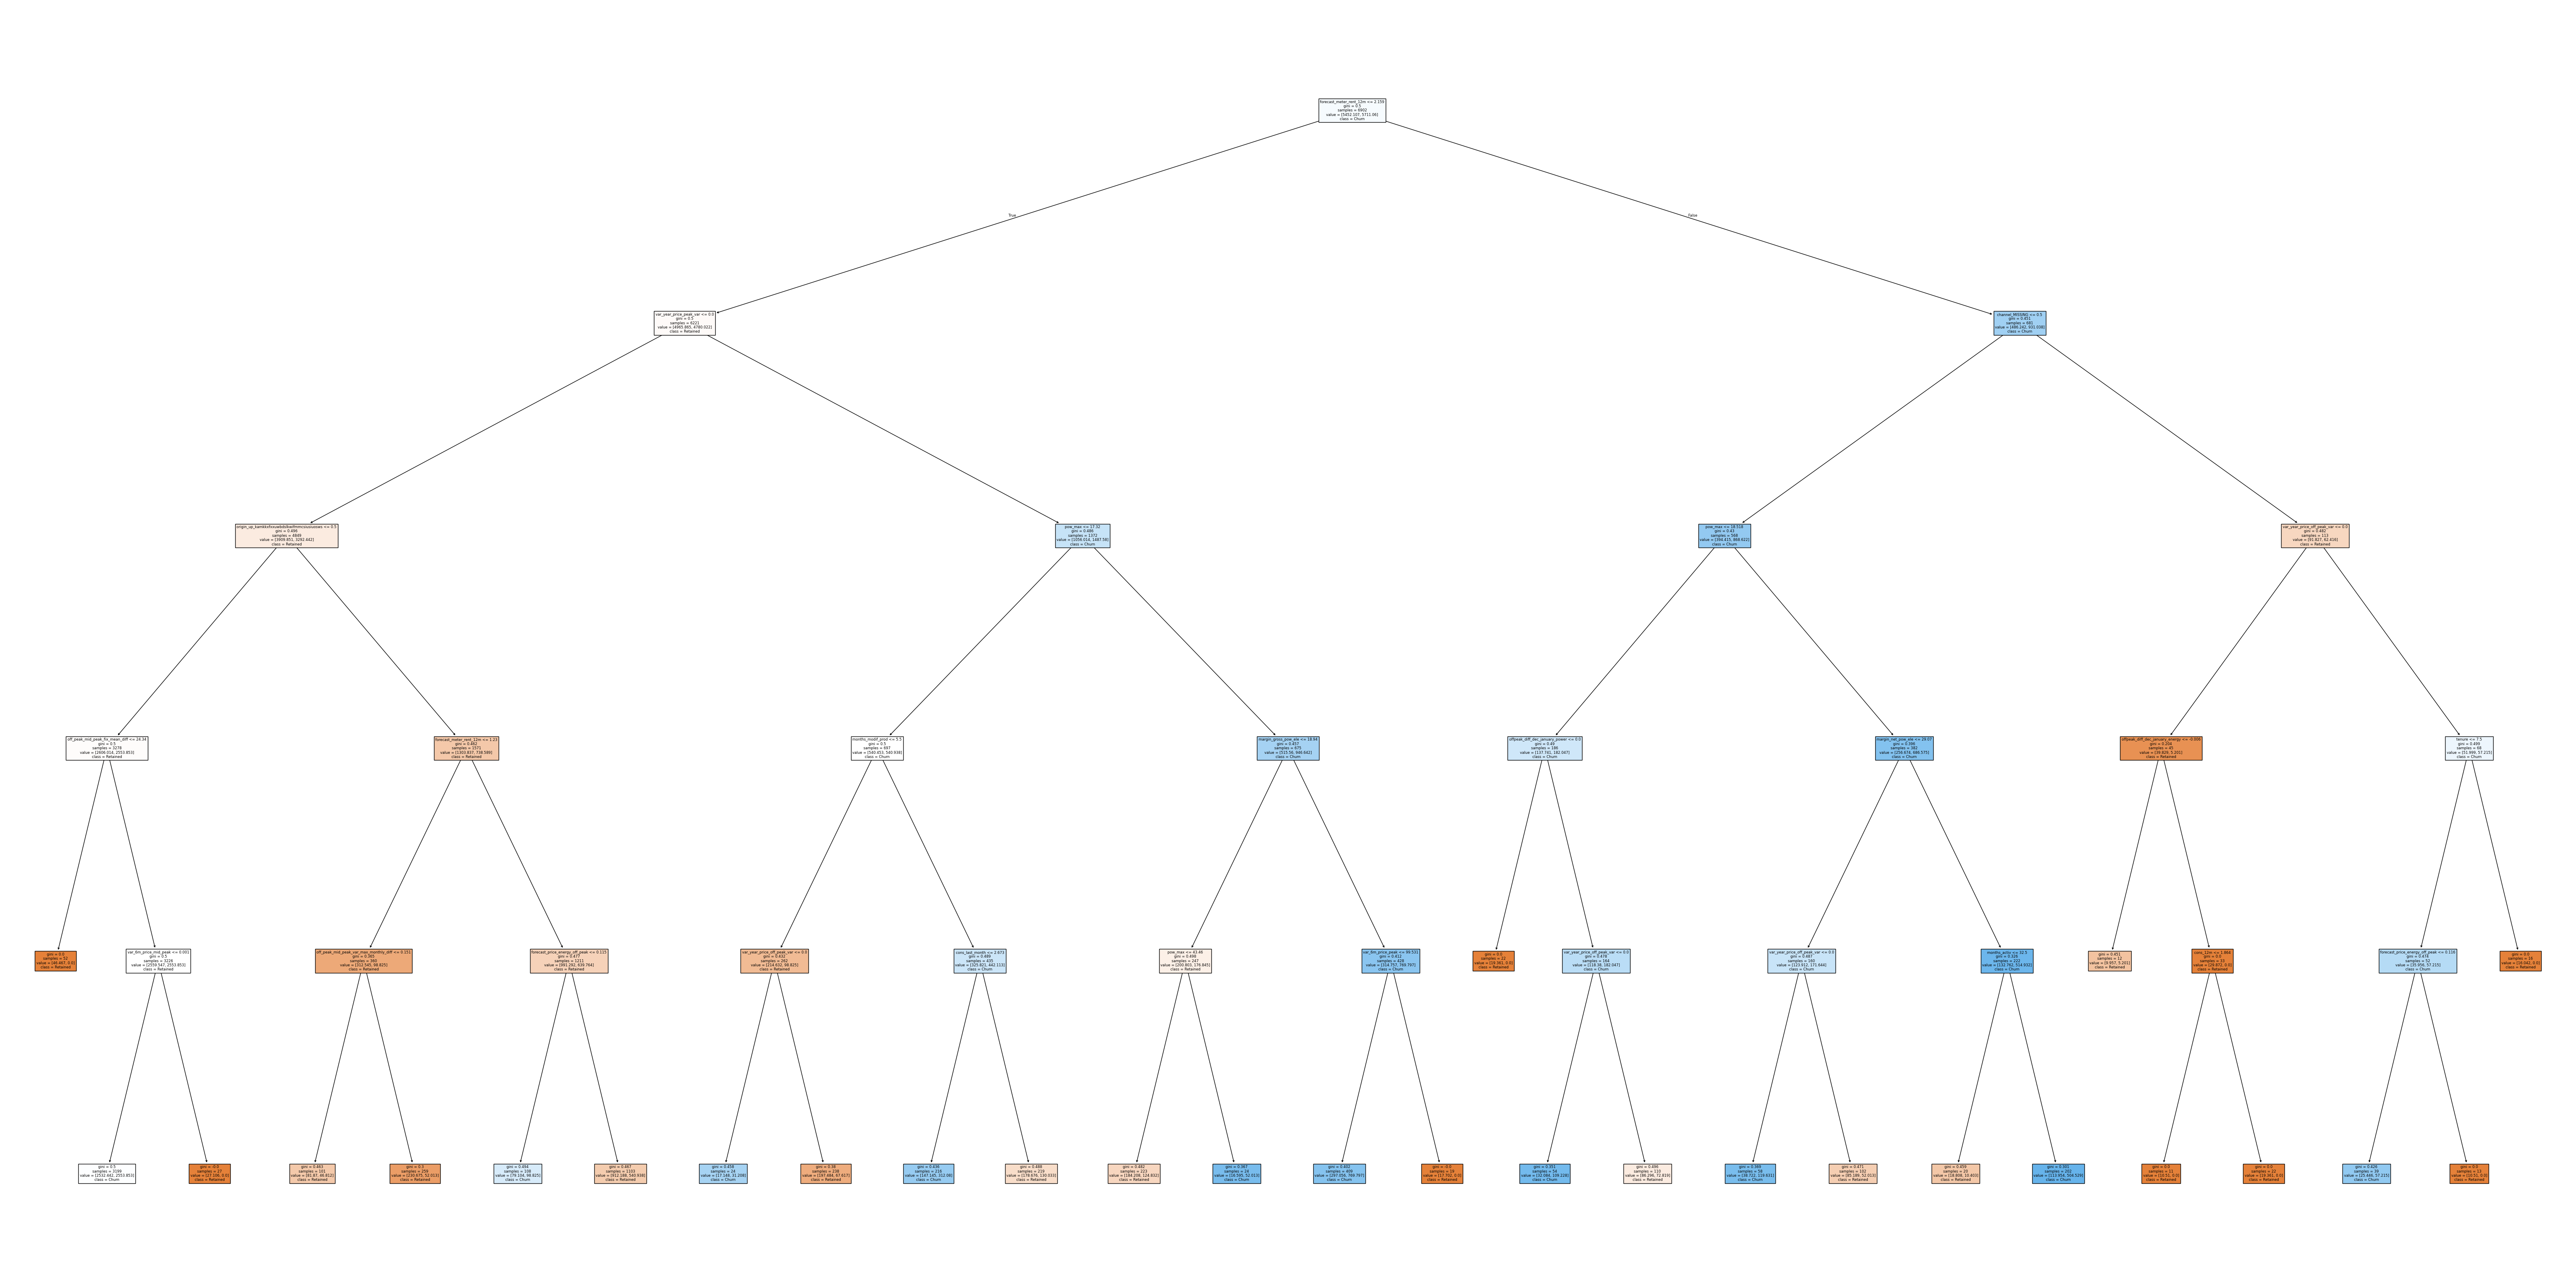

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(80,40))
plot_tree(rf_best.estimators_[1], feature_names = X.columns, class_names=['Retained', "Churn"],filled=True)
plt.show()

# Feature importance

In [ ]:
imp_df2 = pd.DataFrame({
    "Varname": X_train.columns,
    "Imp": rf_best.feature_importances_
})

imp_df2.sort_values(by="Imp", ascending=False)

,Varname,Imp
12,margin_net_pow_ele,0.106624
11,margin_gross_pow_ele,0.103133
49,months_activ,0.065080
60,origin_up_lxidpiddsbxsbosboudacockeimpuepw,0.053982
0,cons_12m,0.050567
...,...,...
57,channel_usilxuppasemubllopkaafesmlibmsdf,0.001222
46,peak_mid_peak_fix_max_monthly_diff,0.001065
30,var_6m_price_mid_peak_fix,0.001032
29,var_6m_price_peak_fix,0.000919


# Summary

The metric that we choose is the recall for class churn=1. We want to correctly predict the churning clients. The recall meassures includes the clients that are correctly predicted as churn and those that churn but where incorrectly predicted as retained. We want to minimize the clients that incorrectly predicted as retained when they should be in churn. In this way we can try to offer them something better so they do not churn.

We have an umbalanced dataset with more retained clients than churn. We need to provide a solution so we can correctly predict the minority of churning clients.

The first parameter that has to be modified is related to the depth of the decision trees so they do not grow so much that they will always overfit.